In [1]:
%pip install matplotlib requests moviepy


Note: you may need to restart the kernel to use updated packages.


# V14c — evidence-weighted IsoNCA × Cells2Pixels port

This is the run to use after a successful V14a. It does not blindly apply all
advice from `convo.txt`, and it does not repeat V14b's three-arm sweep.

The protocol keeps results that survived the completed experiments: the
single-seed `lap_gradnorm` rule, float32 training, 16/128 IsoNCA capacity,
64–96-step rollouts, one coordinate-free interpolated-state decoder, cyclic
learning rate peaking at `1e-3`, and pool-only flushes every 10,000 steps while
preserving Adam and scheduler state. Cartesian coordinates are excluded because
they repeatedly introduced D4 bias without improving V6 quality; neighbor/radial
and phase decoders are excluded because they have no established sharpness gain.

The main new synthesis is intentional: retain the successful IsoNCA's direct
RGBA+binary-auxiliary state supervision at the first and final rollout states,
while adding the missing Cells2Pixels high-resolution decoder loss including
LPIPS. This asks the NCA state to remain semantically meaningful and lets the
LPPN add high-frequency appearance. Damage training remains off until this
undamaged lizard becomes sharp.

Upload `v14a_cells2pixels_lizard_reference_artifacts.tar.gz` to `/workspace/`,
run all cells on CUDA, and download
`v14c_evidence_weighted_isonca_port_artifacts.tar.gz`. Training is independently
resumable from `/workspace/v14c_evidence_weighted_isonca_port/latest_resume.pt`.


In [2]:
#@title Remote GPU setup, repository provenance, and lizard target
from io import BytesIO
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import tarfile
import time

WORKSPACE_ROOT = Path('/workspace') if Path('/workspace').is_dir() else Path.cwd()
repo_candidates = [Path.cwd(), WORKSPACE_ROOT / 'Cells2Pixels']
repo_path = next((p.resolve() for p in repo_candidates if (p / 'models/nca2d.py').is_file()), None)
if repo_path is None:
    repo_path = (WORKSPACE_ROOT / 'Cells2Pixels').resolve()
    subprocess.run([
        'git', 'clone', '--branch', 'isotropic', '--single-branch',
        'https://github.com/IvanLudvig/Cells2Pixels.git', str(repo_path)], check=True)
os.chdir(repo_path)
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

if importlib.util.find_spec('lpips') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips'], check=True)

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn.functional as F
from PIL import Image

from losses.image_loss import ImageLoss
from losses.invariant_image_loss import InvariantImageLoss
from models.nca2d import GrowingNCA, depthwise_conv
from models.isonca import GradNormIsoGrowingNCA
from models.siren import Siren
from training.common import normalize_model_grads
from utils.render import Renderer2D

if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU runtime is required for V14 training')
device = torch.device('cuda')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

revision = subprocess.run(
    ['git', 'rev-parse', 'HEAD'], cwd=repo_path, capture_output=True,
    text=True, check=True).stdout.strip()
repository_sources = {name: file_hash(repo_path / name) for name in (
    'models/nca2d.py', 'models/isonca.py', 'models/siren.py',
    'losses/image_loss.py', 'losses/invariant_image_loss.py', 'utils/render.py')}

TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
if not TARGET_IMAGE_PATH.is_file():
    response = requests.get(
        'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u1f98e.png?raw=true',
        headers={'User-Agent': 'Cells2Pixels V14c'}, timeout=60)
    response.raise_for_status()
    TARGET_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    Image.open(BytesIO(response.content)).convert('RGBA').save(TARGET_IMAGE_PATH)
TARGET_HASH = file_hash(TARGET_IMAGE_PATH)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def cpu_rng_state():
    return dict(
        python=random.getstate(), numpy=np.random.get_state(),
        torch=torch.get_rng_state(), cuda=torch.cuda.get_rng_state_all())

def restore_rng_state(state):
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    torch.cuda.set_rng_state_all(state['cuda'])

print('Repository:', repo_path)
print('Revision:', revision)
print('Target:', TARGET_IMAGE_PATH, TARGET_HASH[:12])
print('GPU:', torch.cuda.get_device_name(0))


Repository: /workspace/Cells2Pixels
Revision: 90e04a0c48e024a7b6844c28ce8aba3c0ff95c75
Target: data/morphology_png/lizard.png 57263fd82e9d
GPU: NVIDIA GeForce RTX 4060 Ti


In [3]:
#@title Evidence-weighted protocol and V14a prerequisite
SLUG = 'v14c_evidence_weighted_isonca_port'
OUTPUT_ROOT = WORKSPACE_ROOT / SLUG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESUME_PATH = OUTPUT_ROOT / 'latest_resume.pt'
BEST_PATH = OUTPUT_ROOT / 'best.pt'
ARCHIVE_PATH = WORKSPACE_ROOT / (SLUG + '_artifacts.tar.gz')

REFERENCE_NAME = 'v14a_cells2pixels_lizard_reference_artifacts.tar.gz'
reference_candidates = [WORKSPACE_ROOT / REFERENCE_NAME, repo_path / REFERENCE_NAME]
REFERENCE_PATH = next((path for path in reference_candidates if path.is_file()), None)
if REFERENCE_PATH is None:
    raise FileNotFoundError('Run V14a and upload ' + REFERENCE_NAME + ' into ' + str(WORKSPACE_ROOT))
with tarfile.open(REFERENCE_PATH) as archive:
    matches = [member for member in archive.getmembers()
               if member.isfile() and Path(member.name).name == 'metrics.json']
    if len(matches) != 1:
        raise RuntimeError('Expected one metrics.json in the V14a artifact')
    reference_metrics = json.loads(archive.extractfile(matches[0]).read())
if reference_metrics.get('status') != 'complete':
    raise RuntimeError('V14a artifact is not complete')
if reference_metrics['config']['target_hash'] != TARGET_HASH:
    raise RuntimeError('V14a used a different target image')

# Proven stable IsoNCA/V6 scale, plus the missing Cells2Pixels image objective.
CHANNELS = 16
FC_DIM = 128
DECODER_WIDTH = 64
GRID_SIZE = 96
RENDER_SCALE = 4
POOL_SIZE = 256
BATCH_SIZE = 2
ROLLOUT_RANGE = (64, 96)
TRAIN_STEPS = 50000
EARLY_SEED_STEPS = 4000
POOL_FLUSH_INTERVAL = 10000
LR_BASE = 1e-5
LR_MAX = 1e-3
LR_STEP_UP = 2000
OVERFLOW_WEIGHT = 10.0
DIRECT_STATE_WEIGHT = 1.0
SUMMARY_INTERVAL = 250
BEST_WINDOW = 500
CHECKPOINT_INTERVAL = 1000
BASE_SEED = 14401
D4_TOLERANCE = 2e-5

alignment_loss = InvariantImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), premultiply_alpha=True, aux_type='binary',
    mirror=True, sharpen=True, l2_weight=1.0,
    include_nca_alpha=True, device=device)
from lpips import LPIPS
lpips_loss = LPIPS(net='vgg', verbose=False).to(device).eval()
lpips_loss.requires_grad_(False)
canonical_target = torch.cat([
    alignment_loss.target_image, alignment_loss.target_image[:, 3:4]], 1)
assert canonical_target.shape == (1, 6, 384, 384)
renderer = Renderer2D(
    scale_factor=RENDER_SCALE, padding='circular', mode='bilinear',
    fs_shader='vanilla', precision=torch.float32)

config = dict(
    protocol='v14c_evidence_weighted_isonca_port_v1',
    model='GradNormIsoGrowingNCA', decoder='coordinate-free interpolated state SIREN',
    channels=CHANNELS, fc_dim=FC_DIM, decoder_width=DECODER_WIDTH,
    grid_size=GRID_SIZE, render_scale=RENDER_SCALE, rendered_size=384,
    pool_size=POOL_SIZE, batch_size=BATCH_SIZE, rollout_range=ROLLOUT_RANGE,
    train_steps=TRAIN_STEPS, early_seed_steps=EARLY_SEED_STEPS,
    seed_rate_after_early=6, pool_flush_interval=POOL_FLUSH_INTERVAL,
    reset_rule='pool only; preserve Adam moments, LR, and cyclic scheduler position',
    scheduler='CyclicLR triangular2, 1e-5 to 1e-3, step_size_up 2000',
    precision='float32; V6 found FFT loss plus long unroll unsafe under fp16',
    objective=(
        'native-pose C2P L1 + L2 + shape L1 + shape L2 + LPIPS; '
        'plus endpoint/first-step direct RGBA+binary-aux state MSE and overflow'),
    direct_state_weight=DIRECT_STATE_WEIGHT,
    overflow_weight=OVERFLOW_WEIGHT,
    gradient_rule='normalize NCA parameter gradients only; decoder gradients unchanged',
    checkpoint_selection='best rolling median-500 rendered quality; final also retained',
    excluded=(
        'no Cartesian arm (known D4 bias/no V6 quality gain); no neighbor or phase arm '
        '(no established sharpness gain); no damage curriculum before a sharp baseline'),
    reference_hash=file_hash(REFERENCE_PATH), target_hash=TARGET_HASH,
    repository_revision=revision, repository_sources=repository_sources,
    torch=torch.__version__, base_seed=BASE_SEED)
(OUTPUT_ROOT / 'config.json').write_text(json.dumps(config, indent=2))
print('V14a mean quality:', reference_metrics['evaluation']['mean']['quality'])
print(json.dumps(config, indent=2))


/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


V14a mean quality: 0.014569013536743114
{
  "protocol": "v14c_evidence_weighted_isonca_port_v1",
  "model": "GradNormIsoGrowingNCA",
  "decoder": "coordinate-free interpolated state SIREN",
  "channels": 16,
  "fc_dim": 128,
  "decoder_width": 64,
  "grid_size": 96,
  "render_scale": 4,
  "rendered_size": 384,
  "pool_size": 256,
  "batch_size": 2,
  "rollout_range": [
    64,
    96
  ],
  "train_steps": 50000,
  "early_seed_steps": 4000,
  "seed_rate_after_early": 6,
  "pool_flush_interval": 10000,
  "reset_rule": "pool only; preserve Adam moments, LR, and cyclic scheduler position",
  "scheduler": "CyclicLR triangular2, 1e-5 to 1e-3, step_size_up 2000",
  "precision": "float32; V6 found FFT loss plus long unroll unsafe under fp16",
  "objective": "native-pose C2P L1 + L2 + shape L1 + shape L2 + LPIPS; plus endpoint/first-step direct RGBA+binary-aux state MSE and overflow",
  "direct_state_weight": 1.0,
  "overflow_weight": 10.0,
  "gradient_rule": "normalize NCA parameter gradients 

In [4]:
#@title Shared rotation/mirror pose and exact D4 operations
def rotate_nchw(image, angle_deg):
    angle = torch.as_tensor(angle_deg * torch.pi / 180.0,
                            device=image.device, dtype=image.dtype)
    c, s = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(image.shape[0], 2, 3, device=image.device, dtype=image.dtype)
    theta[:, 0, 0], theta[:, 0, 1] = c, -s
    theta[:, 1, 0], theta[:, 1, 1] = s, c
    grid = F.affine_grid(theta, image.shape, align_corners=False)
    return F.grid_sample(image, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

def transform_specs(phase_angle, mirrored):
    specs = []
    for angle in (phase_angle, -phase_angle):
        if mirrored:
            specs.extend([('rot_flip_x', angle), ('rot_flip_y', angle),
                          ('flip_x_rot', angle), ('flip_y_rot', angle)])
        else:
            specs.append(('rot', angle))
    return specs

def apply_transform(image, spec):
    operation, angle = spec
    if operation == 'rot': return rotate_nchw(image, angle)
    if operation == 'rot_flip_x': return rotate_nchw(image, angle).flip(-1)
    if operation == 'rot_flip_y': return rotate_nchw(image, angle).flip(-2)
    if operation == 'flip_x_rot': return rotate_nchw(image.flip(-1), angle)
    if operation == 'flip_y_rot': return rotate_nchw(image.flip(-2), angle)
    raise ValueError(operation)

def apply_inverse(image, spec):
    operation, angle = spec
    if operation == 'rot': return rotate_nchw(image, -angle)
    if operation == 'rot_flip_x': return rotate_nchw(image.flip(-1), -angle)
    if operation == 'rot_flip_y': return rotate_nchw(image.flip(-2), -angle)
    if operation == 'flip_x_rot': return rotate_nchw(image, -angle).flip(-1)
    if operation == 'flip_y_rot': return rotate_nchw(image, -angle).flip(-2)
    raise ValueError(operation)

@torch.no_grad()
def select_specs(loss_input):
    losses = alignment_loss.calc_losses(loss_input.detach())
    phase_n = alignment_loss.polar_target.shape[-1]
    selected = []
    for index in range(len(loss_input)):
        best_index = int(losses[index].argmin())
        mirrored = best_index >= phase_n
        angle = 360.0 * (best_index % phase_n) / phase_n
        candidates = []
        for spec in transform_specs(angle, mirrored):
            aligned = apply_transform(loss_input[index:index + 1].detach(), spec)
            candidates.append((float((aligned - canonical_target).square().mean()), spec))
        selected.append(min(candidates, key=lambda item: item[0])[1])
    return selected

def native_targets(specs):
    return torch.cat([apply_inverse(canonical_target, spec) for spec in specs])

def d4_apply(tensor, index):
    transformed = torch.rot90(tensor, index % 4, (-2, -1))
    return transformed.flip(-1) if index >= 4 else transformed


In [5]:
#@title Coordinate-free system and hybrid IsoNCA × Cells2Pixels objective
def make_system():
    set_all_seeds(BASE_SEED)
    model = GradNormIsoGrowingNCA(
        channels=CHANNELS, fc_dim=FC_DIM, padding='circular', update_prob=0.5,
        device=device, precision=torch.float32).to(device)
    decoder = Siren(
        in_features=CHANNELS, coord_dim=2, hidden_features=DECODER_WIDTH,
        hidden_layers=2, out_features=4, outermost_linear=True,
        first_omega_0=10.0, hidden_omega_0=10.0,
        fx='linear', activation='sin', num_frequencies=1,
        disable=False, disable_coords=True).to(device)
    return model, decoder

def fresh_pool(model):
    seed = model.seed(1, GRID_SIZE, GRID_SIZE).detach().cpu()
    return seed.repeat(POOL_SIZE, 1, 1, 1)

def make_optimizer(model, decoder):
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(decoder.parameters()), lr=LR_BASE)
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer, base_lr=LR_BASE, max_lr=LR_MAX,
        step_size_up=LR_STEP_UP, mode='triangular2', cycle_momentum=False)
    return optimizer, scheduler

def render_state(model, decoder, state):
    raw = renderer.render(
        state.permute(0, 2, 3, 1), decoder, None,
        fs_shader='vanilla', hard_clamp=False).float().permute(0, 3, 1, 2)
    state_up = F.interpolate(
        state, scale_factor=RENDER_SCALE, mode='bilinear', align_corners=False)
    living = model.get_living_mask(state_up).to(raw.dtype)
    return raw * living, state_up

def reset_dead_samples(model, state):
    if len(state) <= 1:
        return state
    dead = state[1:, 3:4].sum((1, 2, 3), keepdim=True) < 1e-6
    if dead.any():
        seed = model.seed(len(state) - 1, GRID_SIZE, GRID_SIZE)
        state[1:] = torch.where(dead, seed, state[1:])
    return state

def hybrid_objective(model, decoder, endpoint, first_state):
    rendered, endpoint_up = render_state(model, decoder, endpoint)
    alpha, auxiliary = endpoint_up[:, 3:4], endpoint_up[:, 4:5]
    pose_input = torch.cat([rendered, auxiliary, alpha], 1)
    specs = select_specs(pose_input)
    target = native_targets(specs)

    rgba_l1 = (rendered - target[:, :4]).abs().mean()
    rgba_l2 = (rendered - target[:, :4]).square().mean()
    shape_l1 = (2.0 * alpha - target[:, 5:6]).abs().mean()
    shape_l2 = (2.0 * alpha - target[:, 5:6]).square().mean()
    channels = torch.stack([
        torch.randperm(4, device=device)[:3] for _ in range(len(rendered))])
    rows = torch.arange(len(rendered), device=device)[:, None]
    prediction_crop = rendered[:, :, 64:-64, 64:-64][rows, channels]
    target_crop = target[:, :4, 64:-64, 64:-64][rows, channels]
    perceptual = lpips_loss(prediction_crop, target_crop, normalize=True).mean()

    # The successful IsoNCA directly supervised RGBA+aux state channels. Keep
    # that semantic anchor while the LPPN learns the high-resolution residual.
    first_up = F.interpolate(
        first_state[:, :5], size=(384, 384), mode='bilinear', align_corners=False)
    # C2P's shape loss defines the living alpha at half target-alpha scale.
    # Apply the same factor in the direct semantic view so the two objectives
    # agree instead of asking state alpha to be both 0.5 and 1.0.
    first_semantic = torch.cat([
        first_up[:, :3], 2.0 * first_up[:, 3:4], first_up[:, 4:5]], 1)
    endpoint_semantic = torch.cat([
        endpoint_up[:, :3], 2.0 * endpoint_up[:, 3:4], endpoint_up[:, 4:5]], 1)
    direct_first = (first_semantic - target[:, :5]).square().mean()
    direct_endpoint = (endpoint_semantic - target[:, :5]).square().mean()
    direct_state = 0.5 * (direct_first + direct_endpoint)
    overflow = (endpoint - endpoint.clamp(-2.0, 2.0)).square().mean()
    quality = rgba_l1 + rgba_l2 + shape_l1 + shape_l2 + perceptual
    total = quality + DIRECT_STATE_WEIGHT * direct_state + OVERFLOW_WEIGHT * overflow
    logs = dict(L1=rgba_l1, L2=rgba_l2, **{'Shape L1': shape_l1, 'Shape L2': shape_l2},
                LPIPS=perceptual, Quality=quality, DirectState=direct_state,
                Overflow=overflow, Total=total)
    return total, {name: value.detach() for name, value in logs.items()}

@torch.no_grad()
def decoder_d4_preflight(model, decoder):
    set_all_seeds(BASE_SEED + 9)
    state = torch.randn(1, CHANNELS, GRID_SIZE, GRID_SIZE, device=device) * 0.1
    state[:, 3:4] = 1.0
    base, _ = render_state(model, decoder, state)
    errors = []
    for index in range(1, 8):
        transformed, _ = render_state(model, decoder, d4_apply(state, index))
        errors.append(float((transformed - d4_apply(base, index)).abs().max()))
    return dict(max_abs=max(errors), by_transform=errors,
                d4_pass=max(errors) < D4_TOLERANCE)

model_probe, decoder_probe = make_system()
preflight = decoder_d4_preflight(model_probe, decoder_probe)
print('Coordinate-free decoder preflight:', preflight)
if not preflight['d4_pass']:
    raise RuntimeError('Coordinate-free decoder failed its exact D4 preflight')
del model_probe, decoder_probe
torch.cuda.empty_cache()


Coordinate-free decoder preflight: {'max_abs': 9.685754776000977e-08, 'by_transform': [9.685754776000977e-08, 8.940696716308594e-08, 9.685754776000977e-08, 8.940696716308594e-08, 9.685754776000977e-08, 8.940696716308594e-08, 8.940696716308594e-08], 'd4_pass': True}


In [6]:
#@title Train/resume one stable evidence-weighted run
def save_resume(next_step, model, decoder, optimizer, scheduler, pool,
                history, best_value):
    payload = dict(
        next_step=int(next_step), model=model.state_dict(), decoder=decoder.state_dict(),
        optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
        pool=pool, history=history, best_value=float(best_value),
        rng=cpu_rng_state(), config=config)
    temporary = RESUME_PATH.with_suffix('.tmp')
    torch.save(payload, temporary)
    os.replace(temporary, RESUME_PATH)

set_all_seeds(BASE_SEED)
model, decoder = make_system()
optimizer, scheduler = make_optimizer(model, decoder)
pool = fresh_pool(model)
history, start_step, best_value = [], 0, float('inf')
if RESUME_PATH.is_file():
    payload = torch.load(RESUME_PATH, map_location='cpu', weights_only=False)
    if payload['config'] != config:
        raise RuntimeError('Resume config differs from this notebook; move the old output directory')
    model.load_state_dict(payload['model']); decoder.load_state_dict(payload['decoder'])
    optimizer.load_state_dict(payload['optimizer']); scheduler.load_state_dict(payload['scheduler'])
    pool = payload['pool']; history = payload['history']
    start_step = int(payload['next_step']); best_value = float(payload['best_value'])
    restore_rng_state(payload['rng'])
    print('Resuming at step', start_step)

model.train(); decoder.train()
for step in range(start_step, TRAIN_STEPS):
    pool_flushed = step > 0 and step % POOL_FLUSH_INTERVAL == 0
    if pool_flushed:
        # V2 reset Adam/scheduler and destabilized. V3/V4/V6 established this
        # pool-only form; optimizer moments, current LR, and cycle all survive.
        pool = fresh_pool(model)
        print('step', step, '| pool flushed; Adam and scheduler preserved')

    indices = np.random.choice(POOL_SIZE, BATCH_SIZE, replace=False)
    state = pool[indices].to(device=device, dtype=torch.float32)
    seed_rate = 1 if step < EARLY_SEED_STEPS else 6
    if step % seed_rate == 0:
        state[:1] = model.seed(1, GRID_SIZE, GRID_SIZE)
    state = reset_dead_samples(model, state)
    rollout_steps = int(np.random.randint(ROLLOUT_RANGE[0], ROLLOUT_RANGE[1]))
    first_state = None
    for rollout in range(rollout_steps):
        state, _ = model(state)
        if rollout == 0:
            first_state = state

    optimizer.zero_grad(set_to_none=True)
    loss, logs = hybrid_objective(model, decoder, state, first_state)
    if not torch.isfinite(loss):
        print('step', step + 1, '| non-finite loss; affected trajectories reseeded')
        pool[indices] = model.seed(BATCH_SIZE, GRID_SIZE, GRID_SIZE).detach().cpu()
        continue
    loss.backward()
    gradients_finite = all(
        parameter.grad is None or torch.isfinite(parameter.grad).all()
        for parameter in list(model.parameters()) + list(decoder.parameters()))
    if not gradients_finite:
        optimizer.zero_grad(set_to_none=True)
        pool[indices] = model.seed(BATCH_SIZE, GRID_SIZE, GRID_SIZE).detach().cpu()
        print('step', step + 1, '| non-finite gradients; affected trajectories reseeded')
        continue
    with torch.no_grad():
        normalize_model_grads(model)
        optimizer.step(); scheduler.step()
        pool[indices] = state.detach().cpu()

    row = dict(step=step + 1, rollout_steps=rollout_steps,
               lr=optimizer.param_groups[0]['lr'], pool_flushed=pool_flushed,
               **{name: float(value) for name, value in logs.items()})
    history.append(row)
    if len(history) >= BEST_WINDOW and (step + 1) % SUMMARY_INTERVAL == 0:
        rolling = float(np.median([item['Quality'] for item in history[-BEST_WINDOW:]]))
        row['rolling_quality'] = rolling
        if rolling < best_value:
            best_value = rolling
            torch.save(dict(step=step + 1, rolling_quality=rolling,
                            model=model.state_dict(), decoder=decoder.state_dict()), BEST_PATH)
        print('step', step + 1, '| quality', f"{row['Quality']:.5f}",
              '| median-500', f'{rolling:.5f}', '| best', f'{best_value:.5f}',
              '| lr', f"{row['lr']:.2e}")
    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_resume(step + 1, model, decoder, optimizer, scheduler,
                    pool, history, best_value)

torch.save(model.state_dict(), OUTPUT_ROOT / 'final_model.pth')
torch.save(decoder.state_dict(), OUTPUT_ROOT / 'final_decoder.pth')
if not BEST_PATH.is_file():
    raise RuntimeError('No best checkpoint was selected')
selected = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
torch.save(selected['model'], OUTPUT_ROOT / 'model.pth')
torch.save(selected['decoder'], OUTPUT_ROOT / 'decoder.pth')
(OUTPUT_ROOT / 'history.json').write_text(json.dumps(history, indent=2))
print('Training complete; selected step', selected['step'],
      'with median-500 quality', selected['rolling_quality'])


Resuming at step 41000
step 41250 | quality 0.34116 | median-500 0.32657 | best 0.31556 | lr 1.06e-05
step 41500 | quality 0.35159 | median-500 0.32050 | best 0.31556 | lr 1.07e-05
step 41750 | quality 0.26677 | median-500 0.32321 | best 0.31556 | lr 1.08e-05
step 42000 | quality 0.33613 | median-500 0.32291 | best 0.31556 | lr 1.10e-05
step 42250 | quality 0.25375 | median-500 0.31829 | best 0.31556 | lr 1.08e-05
step 42500 | quality 0.28926 | median-500 0.31792 | best 0.31556 | lr 1.07e-05
step 42750 | quality 0.25140 | median-500 0.31477 | best 0.31477 | lr 1.06e-05
step 43000 | quality 0.37459 | median-500 0.31919 | best 0.31477 | lr 1.05e-05
step 43250 | quality 0.31166 | median-500 0.32241 | best 0.31477 | lr 1.04e-05
step 43500 | quality 0.37391 | median-500 0.32138 | best 0.31477 | lr 1.02e-05
step 43750 | quality 0.31318 | median-500 0.32337 | best 0.31477 | lr 1.01e-05
step 44000 | quality 0.32330 | median-500 0.32559 | best 0.31477 | lr 1.00e-05
step 44250 | quality 0.33556 

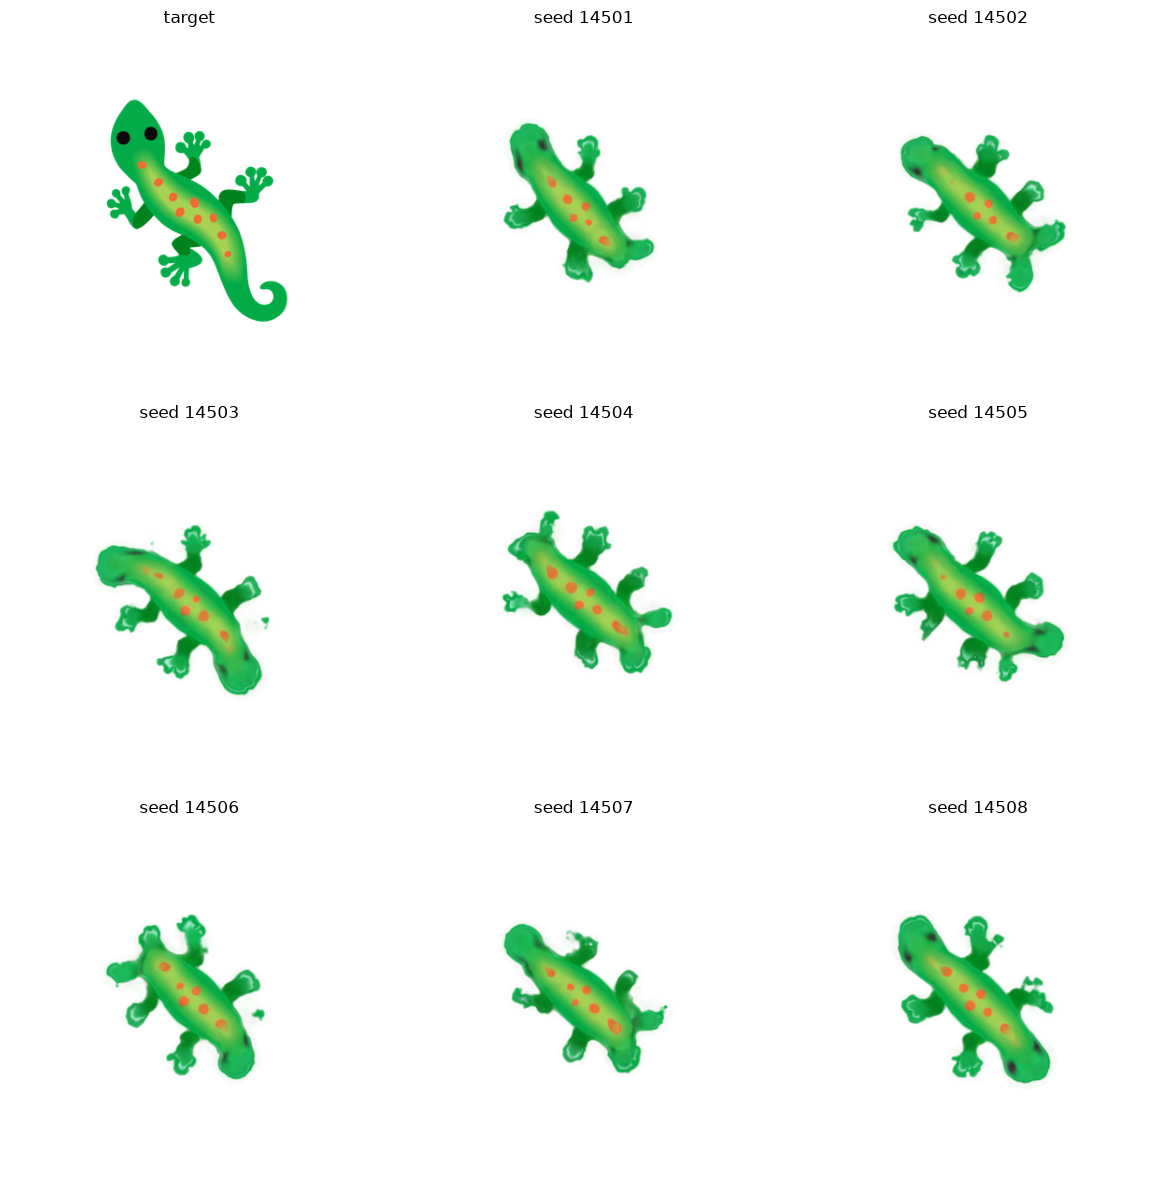

Decision: port_not_yet_reproduced; inspect_direct_state_and_render_panels_before_new_architecture
Age-128 quality / V14a: 29.132526226097124
Pathwise D4: {'state_max_abs': 0.0001302957534790039, 'image_max_abs': 0.0007069706916809082, 'state_pass': True, 'image_pass': True}
Download: /workspace/v14c_evidence_weighted_isonca_port_artifacts.tar.gz


In [7]:
#@title Independent multi-age evaluation, D4 audit, and artifact
model, decoder = make_system()
model.load_state_dict(torch.load(OUTPUT_ROOT / 'model.pth', map_location=device, weights_only=True))
decoder.load_state_dict(torch.load(OUTPUT_ROOT / 'decoder.pth', map_location=device, weights_only=True))
model.eval(); decoder.eval()

@torch.no_grad()
def evaluate(seeds=range(14501, 14509), ages=(96, 128, 192, 256, 384)):
    rows, panel_images = [], []
    for seed in seeds:
        set_all_seeds(int(seed))
        state = model.seed(1, GRID_SIZE, GRID_SIZE)
        for age in range(1, max(ages) + 1):
            state, _ = model(state)
            if age not in ages:
                continue
            rendered, state_up = render_state(model, decoder, state)
            alpha, auxiliary = state_up[:, 3:4], state_up[:, 4:5]
            pose_input = torch.cat([rendered, auxiliary, alpha], 1)
            spec = select_specs(pose_input)[0]
            target = native_targets([spec])
            values = {
                'L1': (rendered - target[:, :4]).abs().mean(),
                'L2': (rendered - target[:, :4]).square().mean(),
                'Shape L1': (2.0 * alpha - target[:, 5:6]).abs().mean(),
                'Shape L2': (2.0 * alpha - target[:, 5:6]).square().mean(),
                'LPIPS RGB': lpips_loss(
                    rendered[:, :3, 64:-64, 64:-64],
                    target[:, :3, 64:-64, 64:-64], normalize=True).mean(),
                'Direct State MSE': (torch.cat([
                    state_up[:, :3], 2.0 * state_up[:, 3:4], state_up[:, 4:5]], 1)
                    - target[:, :5]).square().mean(),
                'Invariant L2': alignment_loss.calc_losses(pose_input).min(-1)[0].mean(),
            }
            row = {name: float(value) for name, value in values.items()}
            row['quality'] = sum(row[name] for name in
                                 ('L1', 'L2', 'Shape L1', 'Shape L2', 'LPIPS RGB'))
            row.update(seed=int(seed), age=int(age), spec=list(spec))
            rows.append(row)
            if age == 128:
                panel_images.append(apply_transform(rendered, spec)[0].cpu())
    by_age = {}
    for age in ages:
        selected_rows = [row for row in rows if row['age'] == age]
        by_age[str(age)] = {
            name: float(np.mean([row[name] for row in selected_rows]))
            for name in values.keys() | {'quality'}}
    return dict(rows=rows, by_age=by_age), panel_images

@torch.no_grad()
def pathwise_d4(steps=192, transform=1):
    set_all_seeds(BASE_SEED + 701)
    seed = model.seed(1, GRID_SIZE, GRID_SIZE)
    masks = (torch.rand(steps, 1, 1, GRID_SIZE, GRID_SIZE, device=device) < 0.5).float()
    base, transformed = seed.clone(), d4_apply(seed, transform)
    for index in range(steps):
        base, _ = model(base, update_mask=masks[index])
        transformed, _ = model(
            transformed, update_mask=d4_apply(masks[index], transform))
    base_image, _ = render_state(model, decoder, base)
    transformed_image, _ = render_state(model, decoder, transformed)
    state_error = float((transformed - d4_apply(base, transform)).abs().max())
    image_error = float((transformed_image - d4_apply(base_image, transform)).abs().max())
    return dict(state_max_abs=state_error, image_max_abs=image_error,
                state_pass=state_error < 1e-3, image_pass=image_error < 1e-3)

evaluation, images = evaluate()
d4 = pathwise_d4()
reference_quality = float(reference_metrics['evaluation']['mean']['quality'])
quality_128 = evaluation['by_age']['128']['quality']
ratio = quality_128 / reference_quality
if ratio <= 1.15 and d4['image_pass']:
    decision = 'evidence_weighted_isotropic_port_candidate'
elif ratio <= 1.50 and d4['image_pass']:
    decision = 'isotropic_port_operational_but_quality_gap_remains'
else:
    decision = 'port_not_yet_reproduced; inspect_direct_state_and_render_panels_before_new_architecture'

target = canonical_target[0, :4].detach().cpu()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for axis, rgba, title in zip(
        axes.flat, [target] + images,
        ['target'] + [f'seed {seed}' for seed in range(14501, 14509)]):
    rgba = rgba.clamp(0, 1)
    rgb = rgba[:3] + (1.0 - rgba[3:4])
    axis.imshow(rgb.permute(1, 2, 0).clamp(0, 1))
    axis.set_title(title); axis.axis('off')
fig.tight_layout()
PANEL_PATH = OUTPUT_ROOT / 'evaluation.png'
fig.savefig(PANEL_PATH, dpi=150); plt.show(); plt.close(fig)

selected = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
metrics = dict(
    status='complete', config=config, preflight=preflight,
    selected=dict(step=selected['step'], rolling_quality=selected['rolling_quality']),
    evaluation=evaluation, pathwise_d4=d4,
    v14a_mean=reference_metrics['evaluation']['mean'], quality_ratio_to_v14a=ratio,
    decision=decision)
(OUTPUT_ROOT / 'metrics.json').write_text(json.dumps(metrics, indent=2))
with tarfile.open(ARCHIVE_PATH, 'w:gz') as archive:
    for name in ('config.json', 'metrics.json', 'model.pth', 'decoder.pth',
                 'history.json', 'evaluation.png'):
        archive.add(OUTPUT_ROOT / name, arcname=SLUG + '/' + name)
print('Decision:', decision)
print('Age-128 quality / V14a:', ratio)
print('Pathwise D4:', d4)
print('Download:', ARCHIVE_PATH)
